In [ ]:
! pip install scikit-fuzzy

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

#### Fuzzy variables

In [2]:
res = 100
roi = ctrl.Antecedent(np.linspace(-1, 1, res), "ROI")
hold_time = ctrl.Antecedent(np.linspace(0, 12, res), "Hold Time")
reward = ctrl.Consequent(np.linspace(-1, 1, res), 'Reward')

#### Membership functions

c:\Andrey\Kakua_Projets\Trading\Bot_RL_v1\venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


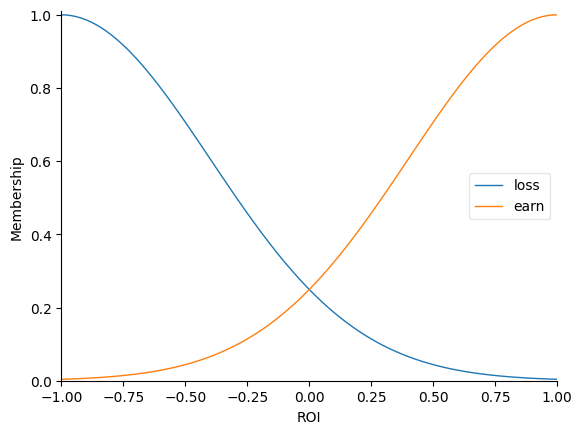

In [3]:
roi["loss"] = fuzz.gaussmf(roi.universe, -1, 0.6)
roi["earn"] = fuzz.gaussmf(roi.universe, 1, 0.6)

roi.view()

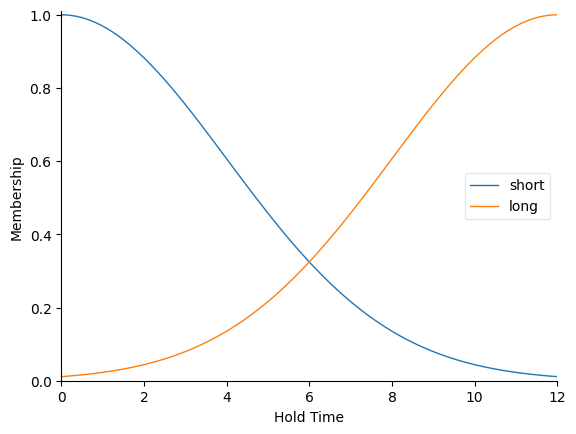

In [4]:
hold_time["short"] = fuzz.gaussmf(hold_time.universe, 0, 4)
hold_time["long"] = fuzz.gaussmf(hold_time.universe, 12, 4)

hold_time.view()

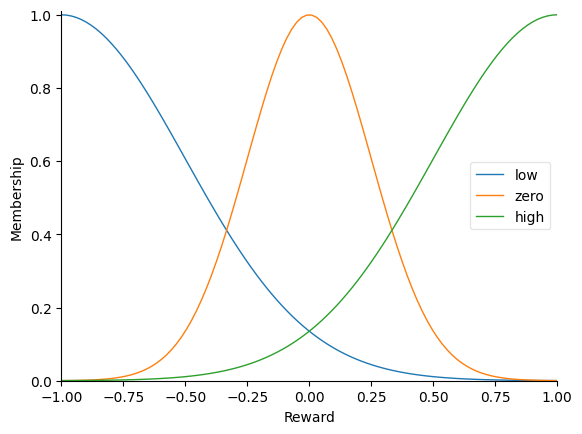

In [5]:
reward["low"] = fuzz.gaussmf(reward.universe, -1, 0.5)
reward["zero"] = fuzz.gaussmf(reward.universe, 0, 0.25)
reward["high"] = fuzz.gaussmf(reward.universe, 1, 0.5)

reward.view()

#### Inference rules

In [6]:
rule1 = ctrl.Rule(roi["earn"] & hold_time["short"], reward['high'])
rule2 = ctrl.Rule(roi["loss"] & hold_time["long"], reward['low'])
rule3 = ctrl.Rule(roi["loss"] & hold_time["short"], reward['zero'])
rule4 = ctrl.Rule(roi["earn"] & hold_time["long"], reward['zero'])

#### Fuzzy inference

In [7]:
system = ctrl.ControlSystem(rules=[rule1, rule2, rule3, rule4])
sim = ctrl.ControlSystemSimulation(system)

In [8]:
roi_space = np.linspace(-1, 1, res)
hold_time_space = np.linspace(0, 12, res)
x, y = np.meshgrid(roi_space, hold_time_space)
z = np.zeros_like(x)

for i in range(res):
    for j in range(res):
        sim.input['ROI'] = x[i, j]
        sim.input['Hold Time'] = y[i, j]
        sim.compute()
        z[i, j] = sim.output['Reward']

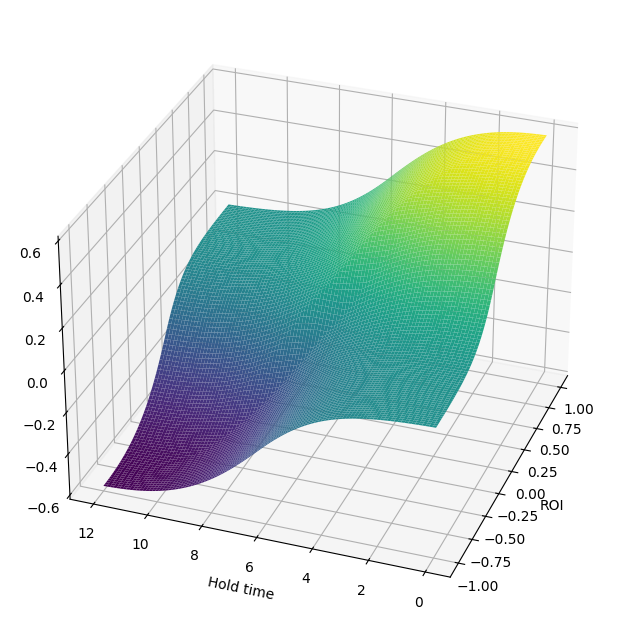

: 

In [ ]:
# Plot the result in pretty 3D with alpha blending
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap='viridis',
                       linewidth=0.4, antialiased=True)

ax.set_xlabel("ROI")
ax.set_ylabel("Hold time")

ax.view_init(30, 200)